In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import *

In [ ]:
main_path = '/content/drive/MyDrive/INCLUDE Subset/Training_set'

In [ ]:
os.path.exists(main_path)

True

In [ ]:
os.listdir(main_path)

['Today',
 'Time',
 'Thankyou',
 'Red',
 'Money',
 'Monsoon',
 'Hospital',
 'Mother',
 'Pocket',
 'Hello',
 'Happy',
 'Friend',
 'Expensive',
 'Father',
 'Cold',
 'Cat',
 'Bad',
 'Car',
 'Cell_Phone',
 'How_Are_You']

In [ ]:
for files in os.walk(main_path):
    print(files)

('/content/drive/MyDrive/INCLUDE Subset/Training_set', ['Today', 'Time', 'Thankyou', 'Red', 'Money', 'Monsoon', 'Hospital', 'Mother', 'Pocket', 'Hello', 'Happy', 'Friend', 'Expensive', 'Father', 'Cold', 'Cat', 'Bad', 'Car', 'Cell_Phone', 'How_Are_You'], [])
('/content/drive/MyDrive/INCLUDE Subset/Training_set/Today', [], ['MVI_9160.MP4', 'MVI_5031.MOV', 'MVI_5471.MOV', 'MVI_5470.MOV', 'MVI_9161.MP4', 'MVI_5032.MOV', 'MVI_4617.MOV', 'MVI_5472.MOV', 'MVI_9162.MP4', 'MVI_5033.MOV', 'MVI_5473.MOV', 'MVI_4618.MOV', 'MVI_4615.mov', 'MVI_4616.mov'])
('/content/drive/MyDrive/INCLUDE Subset/Training_set/Time', [], ['MVI_4669.MOV', 'MVI_4667.MOV', 'MVI_4668.MOV', 'MVI_4670.MOV', 'MVI_5078.MOV', 'MVI_5077.MOV', 'MVI_5526.MOV', 'MVI_5079.MOV', 'MVI_5524.MOV', 'MVI_5525.MOV', 'MVI_9201.MP4', 'MVI_9202.MP4', 'MVI_5527.MOV', 'MVI_9204.MP4', 'MVI_9203.MP4'])
('/content/drive/MyDrive/INCLUDE Subset/Training_set/Thankyou', [], ['MVI_0006.MOV', 'MVI_0008.MOV', 'MVI_0007.MOV', 'MVI_0058.MOV', 'MVI_0059.MO

In [ ]:
words = os.listdir(main_path)
words

['Today',
 'Time',
 'Thankyou',
 'Red',
 'Money',
 'Monsoon',
 'Hospital',
 'Mother',
 'Pocket',
 'Hello',
 'Happy',
 'Friend',
 'Expensive',
 'Father',
 'Cold',
 'Cat',
 'Bad',
 'Car',
 'Cell_Phone',
 'How_Are_You']

In [ ]:
len(words)

20

Training Set


In [ ]:
main_path = '/content/drive/MyDrive/INCLUDE Subset/Training_set'
new_folder = '/content/Extracted_images'
for word in words:
    path = os.path.join(main_path,word)
    video = os.listdir(path)
    for video_idx, video_name in enumerate(video):
        working_folder = os.path.join(new_folder,word,f'video{video_idx}')
        os.makedirs(working_folder, exist_ok=True)

        cap = cv2.VideoCapture(os.path.join(path, video_name))
        c = 0
        while cap.isOpened():
            r, frame = cap.read()
            if not r:
                break
            frame = cv2.resize(frame,(1280,720))
            if r == True:
                frame_name = f'frame{c:04d}.jpg'
                full_path = os.path.join(working_folder,frame_name)
                cv2.imwrite(full_path, frame)
                c = c+1
            else:
                break
        cap.release()
print('frames uploaded')

frames uploaded


In [ ]:
base_options_hand = python.BaseOptions(model_asset_path='/content/hand_landmarker.task')
options_hand = vision.HandLandmarkerOptions(base_options=base_options_hand, num_hands=2, running_mode=vision.RunningMode.IMAGE)
hand_detector = vision.HandLandmarker.create_from_options(options_hand)

base_options_face = python.BaseOptions(model_asset_path='/content/face_landmarker.task')
options_face = vision.FaceLandmarkerOptions(base_options=base_options_face, num_faces=1, running_mode=vision.RunningMode.IMAGE)
face_detector = vision.FaceLandmarker.create_from_options(options_face)

base_options_pose = python.BaseOptions(model_asset_path='/content/pose_landmarker_lite.task')
options_pose = vision.PoseLandmarkerOptions(base_options=base_options_pose, running_mode=vision.RunningMode.IMAGE)
pose_detector = vision.PoseLandmarker.create_from_options(options_pose)

In [ ]:
img_folder = '/content/Extracted_images'
data = []

for word in os.listdir(img_folder):
    imgs = os.path.join(img_folder, word)
    for folder in os.listdir(imgs):
        video_path = os.path.join(imgs, folder)
        extracted_frames = sorted(f for f in os.listdir(video_path) if f.endswith('.jpg'))

        sequence = []

        for frame in extracted_frames:
            frame_path = os.path.join(video_path, frame)
            image = cv2.imread(frame_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
            hand_result = hand_detector.detect(mp_image)
            face_result = face_detector.detect(mp_image)
            pose_result = pose_detector.detect(mp_image)


            lhand = [[0,0,0]]*21
            rhand = [[0,0,0]]*21
            if hand_result.hand_landmarks:
                for idx, hand_landmarks in enumerate(hand_result.hand_landmarks):
                    handedness_label = hand_result.handedness[idx][0].category_name
                    landmarks_list = [[lm.x, lm.y, lm.z] for lm in hand_landmarks]

                    if handedness_label == 'Left':
                        lhand = landmarks_list
                    elif handedness_label == 'Right':
                        rhand = landmarks_list


            if face_result.face_landmarks:
                face = [[lm.x, lm.y, lm.z] for lm in face_result.face_landmarks[0]]
            else:
                face = [[0,0,0]]*478


            if pose_result.pose_landmarks:
                pose = [[lm.x, lm.y, lm.z] for lm in pose_result.pose_landmarks[0]]
            else:
                pose = [[0,0,0]]*33


            landmark = np.array(lhand + rhand + face + pose).flatten()
            sequence.append(landmark)
        data.append([word,sequence])

In [ ]:
data = pd.DataFrame(data)

In [ ]:
data

,0,1
0,Father,"[[0.5611668825149536, 0.7218419909477234, -1.2..."
1,Father,"[[0.6027348041534424, 0.7258485555648804, 7.93..."
2,Father,"[[0.5785537958145142, 0.8265909552574158, 6.13..."
3,Father,"[[0.6025001406669617, 0.8295400142669678, 2.99..."
4,Father,"[[0.5962477922439575, 0.847074031829834, 5.474..."
...,...,...
359,How_Are_You,"[[0.5861740112304688, 0.755662202835083, 7.968..."
360,How_Are_You,"[[0.6062202453613281, 0.7556131482124329, 2.05..."
361,How_Are_You,"[[0.5868516564369202, 0.7427012324333191, 7.43..."
362,How_Are_You,"[[0.5337210297584534, 0.7658556699752808, 3.45..."


In [ ]:
data.shape

(364, 2)

In [ ]:
data[0].value_counts()

,count
0,
Thankyou,21
Happy,21
How_Are_You,21
Hello,21
Bad,21
Hospital,20
Father,20
Pocket,20
Cold,20


In [ ]:
from sklearn.utils import shuffle

In [ ]:
data = shuffle(data, random_state=42)

In [ ]:
data

,0,1
193,Monsoon,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
33,Pocket,"[[0.5996125936508179, 0.8466536998748779, 4.43..."
15,Father,"[[0.5942739844322205, 0.8197792172431946, 6.02..."
347,How_Are_You,"[[0.5564343929290771, 0.7760474681854248, 4.27..."
57,Thankyou,"[[0.5350953340530396, 0.7834036946296692, 4.61..."
...,...,...
71,Thankyou,"[[0.592025876045227, 0.7359745502471924, 1.164..."
106,Car,"[[0.482477068901062, 0.8354554176330566, -5.46..."
270,Happy,"[[0.5638928413391113, 0.8071364164352417, 1.33..."
348,How_Are_You,"[[0.5914045572280884, 0.7461856603622437, 1.56..."


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 193 to 102
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       364 non-null    object
 1   1       364 non-null    object
dtypes: object(2)
memory usage: 8.5+ KB


In [ ]:
fixed_num = 75
padded_seq = []
for seq in data[1]:
    seq = np.array(seq)
    if len(seq) > fixed_num:
       resize = np.linspace(start=0, stop=len(seq) - 1, num=fixed_num)
       resize = np.round(resize).astype(int)
       new = seq[resize]

    else:
        seq_len = fixed_num - len(seq)
        pad = np.zeros((seq_len,1659))
        new = np.vstack([seq,pad])

    padded_seq.append(new)

In [ ]:
encoder = LabelEncoder()
data[0] = encoder.fit_transform(data[0])

In [ ]:
x = np.array(padded_seq, dtype=float)
y = data[0]

In [ ]:
x

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          4.80045289e-01,  9.92702127e-01,  1.27119541e-01],
        [ 4.12356645e-01,  8.31122518e-01, -6.83921044e-08, ...,
          4.57279593e-01,  8.87213945e-01,  1.43568650e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          4.60564226e-01,  9.42689419e-01,  1.75054252e-01],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 5.99612594e-01,  8.46653700e-01,  4.43202453e-08, ...,
          4.81640488e-01,  1.06177855e+00,  2.18306899e-01],
        [ 5.99888980e-01,  8.46805811e-01,  5.28034896e-08, ...,
          4.82307255e-01,  9.01551664e

In [ ]:
y

,0
193,13
33,15
15,6
347,11
57,17
...,...
71,17
106,1
270,8
348,11


In [ ]:
x.shape

(364, 75, 1659)

In [ ]:
y.shape

(364,)

In [ ]:
size = int(round(len(x)*0.70))
val_size = int(round(len(x)*0.15))
x_train = x[:size]
y_train = y[:size]
x_val = x[size:size + val_size]
y_val = y[size:size + val_size]
x_test = x[size + val_size:]
y_test = y[size + val_size:]

In [ ]:
scaler = StandardScaler()
x_train_reshape = x_train.reshape(-1, x_train.shape[-1])
x_train_scaled = scaler.fit_transform(x_train_reshape)
x_train = x_train_scaled.reshape(x_train.shape)

In [ ]:
x_val_reshape = x_val.reshape(-1, x_val.shape[-1])
x_val_scaled = scaler.fit_transform(x_val_reshape)
x_val = x_val_scaled.reshape(x_val.shape)

In [ ]:
x_test_reshape = x_test.reshape(-1, x_test.shape[-1])
x_test_scaled = scaler.transform(x_test_reshape)
x_test = x_test_scaled.reshape(x_test.shape)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)

(255, 75, 1659)
(255,)
(55, 75, 1659)
(55,)
(54, 75, 1659)
(54,)


In [ ]:
x.min(), x.max()

(np.float64(-1.179725170135498), np.float64(1.5029606819152832))

In [ ]:
x_train.min(), x_train.max()

(np.float64(-138.2895513045811), np.float64(138.28955130458445))

In [ ]:
x_val.min(), x_val.max()

(np.float64(-9.29588244847018), np.float64(4.781805542411168))

In [ ]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(75,1659)))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='tanh', kernel_regularizer=l2(0.1)))
model.add(Dense(20, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_73 (LSTM)                  │ (None, 75, 128)        │       915,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_74 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 970,324 (3.70 MB)

 Trainable params: 970,324 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
callback = EarlyStopping(monitor='val_loss',patience=20,verbose=1,mode='auto',restore_best_weights=True)

In [ ]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=500, callbacks=callback)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.0902 - loss: 9.4727 - val_accuracy: 0.1455 - val_loss: 9.1730
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.0941 - loss: 9.0185 - val_accuracy: 0.0909 - val_loss: 8.8478
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.1098 - loss: 8.6372 - val_accuracy: 0.0909 - val_loss: 8.5127
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1765 - loss: 8.2455 - val_accuracy: 0.2182 - val_loss: 8.1557
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1922 - loss: 7.9139 - val_accuracy: 0.2000 - val_loss: 7.8485
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2275 - loss: 7.5602 - val_accuracy: 0.2364 - val_loss: 7.5229
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2392 - loss: 7.2391 - val_accuracy: 0.2364 - val_loss: 7.2311
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2784 - loss: 6.9401 - val_accuracy: 0.2545 - val_loss

In [ ]:
pred = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


In [ ]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7407 - loss: 1.3079


[1.3078759908676147, 0.7407407164573669]

In [ ]:
model.evaluate(x_val,y_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8545 - loss: 0.7810


[0.7810086607933044, 0.8545454740524292]

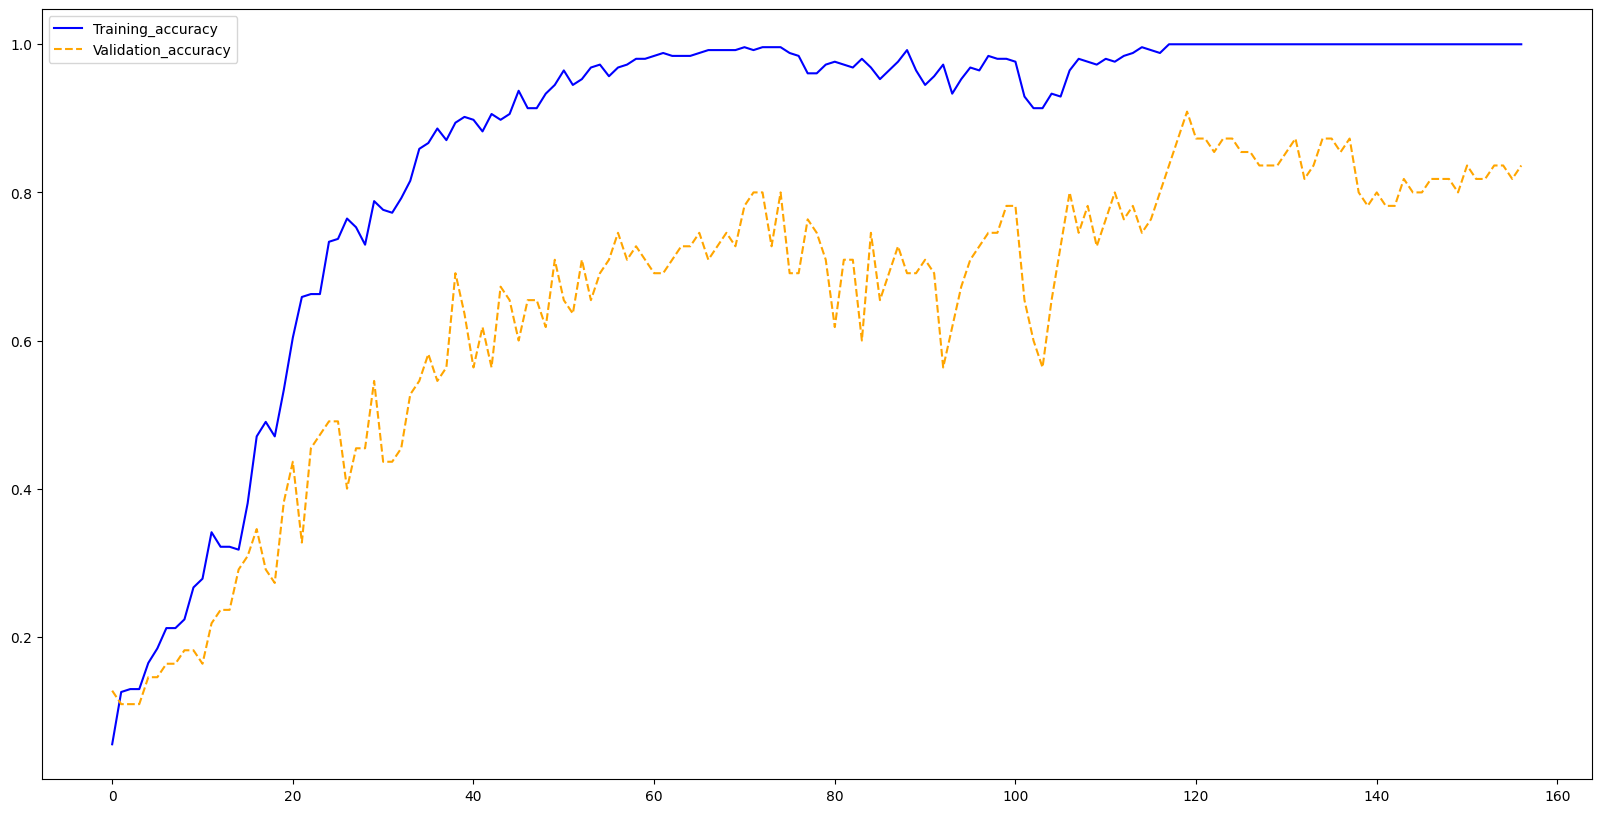

In [ ]:
plt.figure(figsize=(20,10))
plt.plot(history.history['accuracy'], label='Training_accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation_accuracy', color='orange', linestyle='--')
plt.legend()
plt.show()

In [ ]:
y_pred = np.argmax(pred, axis=1)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7407407407407407

In [ ]:
classification_report = classification_report(y_test, y_pred)
print(classification_report)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       0.57      1.00      0.73         4
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       0.50      0.33      0.40         3
           8       1.00      1.00      1.00         3
           9       0.50      0.33      0.40         3
          10       0.75      1.00      0.86         3
          11       1.00      0.83      0.91         6
          12       0.33      0.33      0.33         3
          13       1.00      1.00      1.00         1
          14       0.75      1.00      0.86         3
          15       1.00      0.33      0.50         3
          16       0.33      0.50      0.40         2
          17       1.00    

In [ ]:
model.save("isl_recognition_model.keras")